# Tarea Semanal 5: Estimación espectral. Ventanas en acción!
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051  
**Docente:** Mariano Llamedo Soria
 
---
## 1. Introducción

Comenzaremos con la generación de la siguiente señal:

$$x(n) = a_0 \cdot sen(\Omega_1 \cdot n) + n_a(n)$$

siendo

$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$$

$$\Omega_0 = \frac{\pi}{2}$$

siendo la variable aleatoria definida por la siguiente distribución de probabilidad:

$$f_r \sim \mathcal{U}(-2, 2)$$

$$n_a \sim \mathcal{N}(0, \sigma^2)$$

### Diseño de Estimadores

Diseñe los siguientes estimadores, de **amplitud $a_1$**:

$$\hat{a}_1^i = |X_w^i(\Omega_0)| = |\mathcal{F}\{x(n) \cdot w_i(n)\}|$$

para la $i$-ésima realización y la $w$-ésima ventana (ver detalles debajo).

Y de **frecuencia $\Omega_1$**:

$$\hat{\Omega}_1^i = \arg \max_{\Omega} \{|X_w^i(\Omega)|\}$$

para cada una de las ventanas:

* **rectangular** (sin ventana),
* **flattop**
* **blackmanharris**
* **otra** que elija de [scipy.signal.windows](https://docs.scipy.org/doc/scipy/reference/signal.windows.html)

### Consignas para la experimentación

* Considere 200 realizaciones (muestras tomadas de $f_r$) de 1000 muestras para cada experimento.
* Parametrice para SNR's de 3 y 10 db (**Ayuda:** calibre $a_0$ para que la potencia de la senoidal sea 1 W).

### Se pide:

1) Realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada. Recuerde incluir las ventanas **rectangular** (sin ventana), **flattop** y **blackmanharris** y otras que considere.

#### Estimación de Amplitud

| | $s_a$ | $v_a$ |
| :--- | :---: | :---: |
| **Rectangular** | | |
| **Flat-top** | | |
| **Blackman** | | |
| **otras** | | |

#### Estimación de Frecuencia

| | $s_a$ | $v_a$ |
| :--- | :---: | :---: |
| **Rectangular** | | |
| **Flat-top** | | |
| **Blackman** | | |
| **otras** | | |

### Ayuda: 
Puede calcular experimentalmente el sesgo y la varianza de un estimador:

$$\hat{a}_0 = |X_w^i(\Omega_0)|$$

siendo

$$s_a = E\{\hat{a}_0\} - a_0$$

$$v_a = var\{\hat{a}_0\} = E\{(\hat{a}_0 - E\{\hat{a}_0\})^2\}$$

y pueden aproximarse cuando consideramos los valores esperados como las medias muestrales:

$$E\{\hat{a}_0\} = \hat{\mu}_a = \frac{1}{M} \sum_{j=0}^{M-1} \hat{a}_j$$

$$s_a = \hat{\mu}_a - a_0$$

$$v_a = \frac{1}{M} \sum_{j=0}^{M-1} (\hat{a}_j - \hat{\mu}_a)^2$$

### Bonus:

* 💎 Analice el efecto del zero-padding para el estimador $\hat{\Omega}_1$
* 🤡 Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.


## 2. Configuración
En esta sección se importan las librerías necesarias (`numPy`, `scipy.signal.windows` y `matplotlib.pyplot`) y se definen tanto los algoritmos de trabajo, como los parámetros globales de la simulación (frecuencia de muestreo, Resolución espectral, etc).

In [19]:
# Importación de módulos que utilizaremos en esta tarea semanal 5:
import numpy as np
import scipy.signal.windows as windows
import matplotlib.pyplot as plt

#%% DFT
def mi_funcion_DFT(xx):
    N = len(xx)
    n = np.arange(N)
    k = n.reshape((N, 1))
    matriz_exponencial = np.exp(-2j * np.pi * k * n / N)
    XX = np.dot(matriz_exponencial, xx)
    return XX
#%% Senoidal
def MT_Senoidal(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    ts = 1/fs
    tt = np.arange(0.0, nn*ts, ts)
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    return tt, xx

#%% PARAMETROS
N = 1000          
fs = 1000         
snr_db = [3,10]
a0 = np.sqrt(2) 
Omega0 = np.pi / 2
R = 200
ventanas = {
    'Rectangular': windows.boxcar(N),
    'Flat-top': windows.flattop(N),
    'Blackman': windows.blackmanharris(N),
    'Hamming': windows.hamming(N)
}

## 3. Generación y Visualización de Análisis
Se procede a instanciar los algoritmos utilizando las funciones definidas anteriormente y se realiza un ploteo de la estimación de amplitud y frecuencia de cada ventana propuesta con una SNR de 3dB.

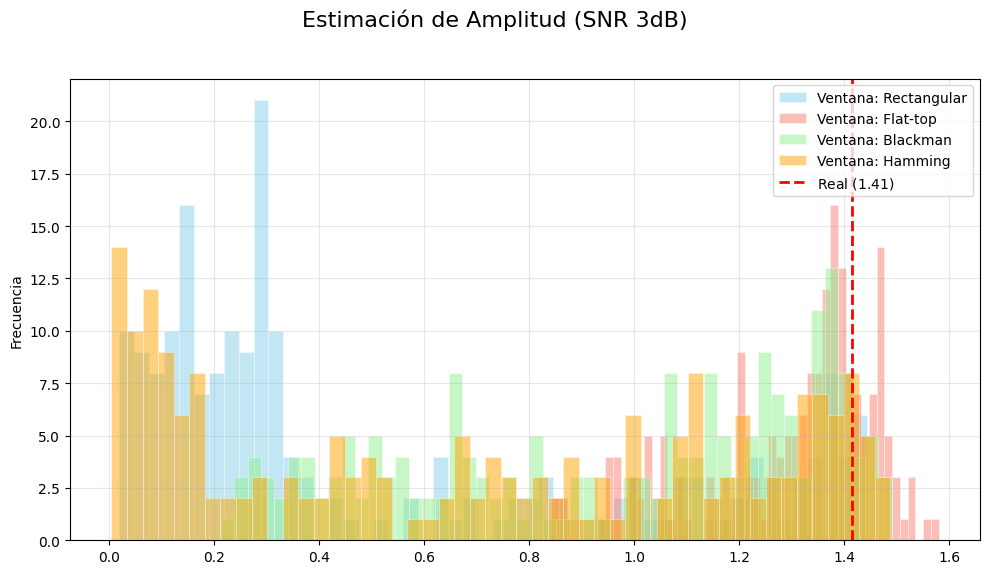

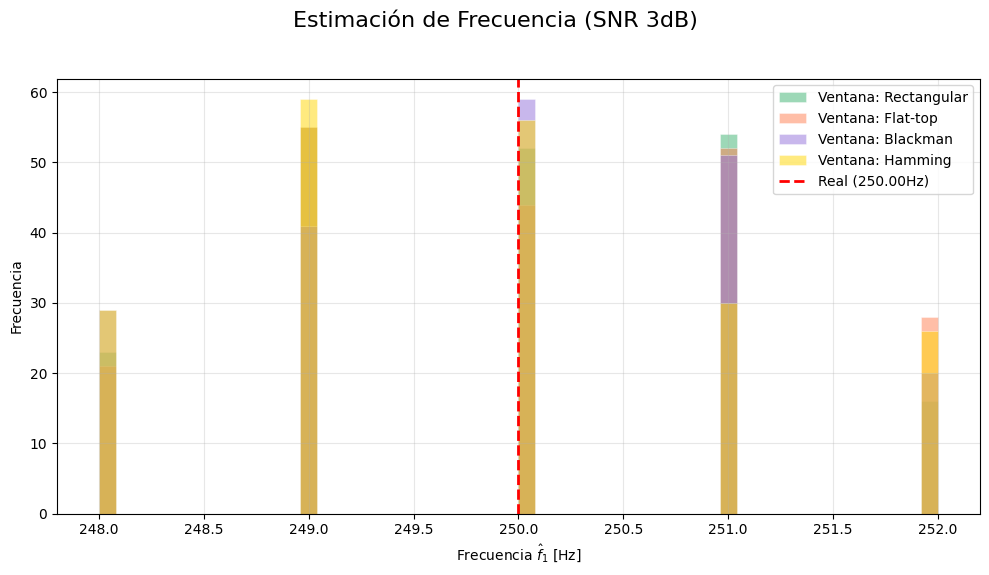

In [20]:
#%% SIMULACIÓN CON SNR = 3dB
hist_amp = {k: [] for k in ventanas.keys()}
hist_freq = {k: [] for k in ventanas.keys()}
sigma = np.sqrt(1 / (10**(snr_db[0] /10)))

#%% 200 realizaciones
for nombre, w in ventanas.items():
    cg = np.sum(w) / N # Ganancia coherente para corregir amplitud
    for t in range(R):
        na = np.random.normal(0, sigma, N)
        fr = np.random.uniform(-2, 2)
        Omega1 = Omega0 + fr * (2 * np.pi / N)
        f1_hz = Omega1 * fs / (2 * np.pi)
        t, x_pura = MT_Senoidal(a0, 0, f1_hz, N, fs)
        x_ruidosa = x_pura + na
        
        #X = mi_funcion_DFT(x_ruidosa * w)
        X = np.fft.fft(x_ruidosa * w)
                
        estim_amp = np.abs(X[int(N/4)]) / (N * cg / 2)
        hist_amp[nombre].append(estim_amp)
        
        estim_frec = np.argmax(np.abs(X[:N//2]))
        hist_freq[nombre].append(estim_frec * (fs / N))

#%% FIGURA 1: ESTIMACIÓN DE AMPLITUD (SNR 3dB)
colores = ['skyblue', 'salmon', 'lightgreen', 'orange']

fig1, ax = plt.subplots(figsize=(10, 6))
fig1.suptitle(f'Estimación de Amplitud (SNR {snr_db[0]}dB)', fontsize=16)

for i, (nombre, datos) in enumerate(hist_amp.items()):
    color_actual = colores[i % len(colores)]
    
    ax.hist(datos, bins=50, alpha=0.5, color=color_actual, 
            edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Real (${a0:.2f}$)')

ax.set_ylabel('Frecuencia')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#%% FIGURA 2: ESTIMACIÓN DE FRECUENCIA (SNR 3dB)
colores_freq = ['mediumseagreen', 'coral', 'mediumpurple', 'gold']

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.suptitle(f'Estimación de Frecuencia (SNR {snr_db[0]}dB)', fontsize=16)

f0_hz = (Omega0 * fs) / (2 * np.pi) 


for i, (nombre, datos) in enumerate(hist_freq.items()):
    color_actual = colores_freq[i % len(colores_freq)]
      
    ax2.hist(datos, bins=50, alpha=0.5, color=color_actual, 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax2.axvline(f0_hz, color='red', linestyle='--', linewidth=2, label=f'Real ({f0_hz:0.2f}Hz)')


ax2.set_xlabel('Frecuencia $\hat{f}_1$ [Hz]')
ax2.set_ylabel('Frecuencia')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Tablas comparativas para 3dB

In [21]:
#%% TABLAS DE ESTIMACIÓN DE AMPLITUD Y FRECUENCIA 3dB

f0_hz = (Omega0 * fs) / (2 * np.pi) # Frecuencia real en Hz para comparar

# --- TABLA 1: ESTIMACIÓN DE AMPLITUD ---
print("\n" + "="*70)
print(f"{'ESTIMACIÓN DE AMPLITUD (SNR ' + str(snr_db[0]) + ' dB)':^70}")
print("="*70)
print(f"{'Ventana':<20} | {'Sesgo (sa)':>20} | {'Varianza (va)':>20}")
print("-"*70)

for nombre in ventanas.keys():
    datos = hist_amp[nombre]
    mu_a = np.mean(datos)
    sa = mu_a - a0           
    va = np.var(datos)       
    
    label = nombre if nombre != 'Hamming' else 'Hamming (otras)'
    print(f"{label:<20} | {sa:>20.6f} | {va:>20.6e}")

print("-" * 70)

# --- TABLA 2: ESTIMACIÓN DE FRECUENCIA ---
print("\n" + "="*70)
print(f"{'ESTIMACIÓN DE FRECUENCIA (SNR ' + str(snr_db[0]) + ' dB)':^70}")
print("="*70)
print(f"{'Ventana':<20} | {'Sesgo (sf)':>20} | {'Varianza (vf)':>20}")
print("-"*70)

for nombre in ventanas.keys():
    datos = hist_freq[nombre]
    mu_f = np.mean(datos)
    sf = mu_f - f0_hz        # Sesgo respecto a la frecuencia real
    vf = np.var(datos)       # Varianza de la estimación de frecuencia
    
    label = nombre if nombre != 'Hamming' else 'Hamming (otras)'
    print(f"{label:<20} | {sf:>20.6f} | {vf:>20.6e}")

print("="*70)



                  ESTIMACIÓN DE AMPLITUD (SNR 3 dB)                   
Ventana              |           Sesgo (sa) |        Varianza (va)
----------------------------------------------------------------------
Rectangular          |            -0.889867 |         2.213944e-01
Flat-top             |            -0.121110 |         2.883819e-02
Blackman             |            -0.453516 |         1.443734e-01
Hamming (otras)      |            -0.720474 |         2.598671e-01
----------------------------------------------------------------------

                 ESTIMACIÓN DE FRECUENCIA (SNR 3 dB)                  
Ventana              |           Sesgo (sf) |        Varianza (vf)
----------------------------------------------------------------------
Rectangular          |            -0.075000 |         1.319375e+00
Flat-top             |             0.055000 |         1.511975e+00
Blackman             |            -0.040000 |         1.438400e+00
Hamming (otras)      |            -0.175

## 5. Generación y Visualización de Análisis
Se procede a instanciar los algoritmos utilizando las funciones definidas anteriormente y se realiza un ploteo de la estimación de amplitud y frecuencia de cada ventana propuesta con una SNR de 10dB.

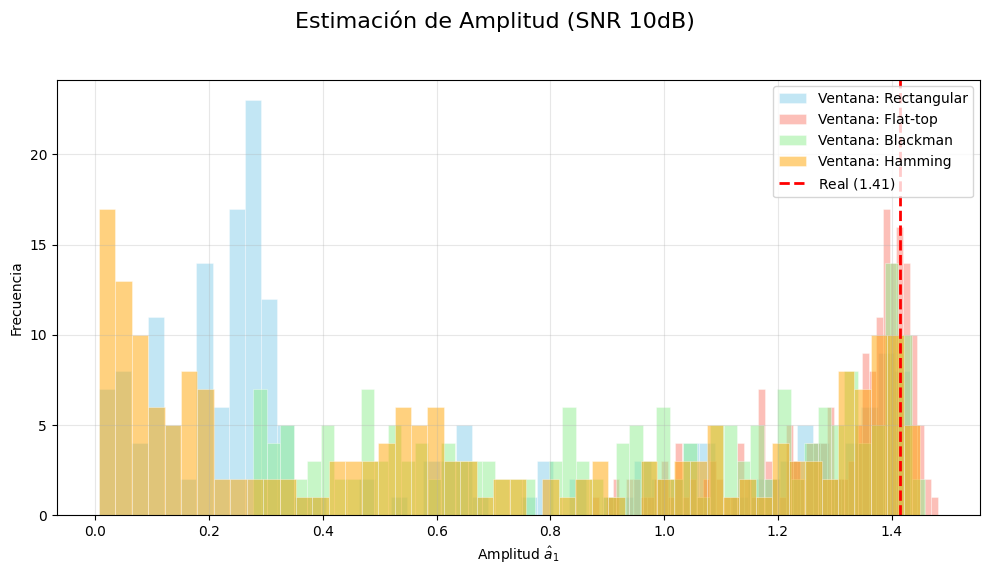

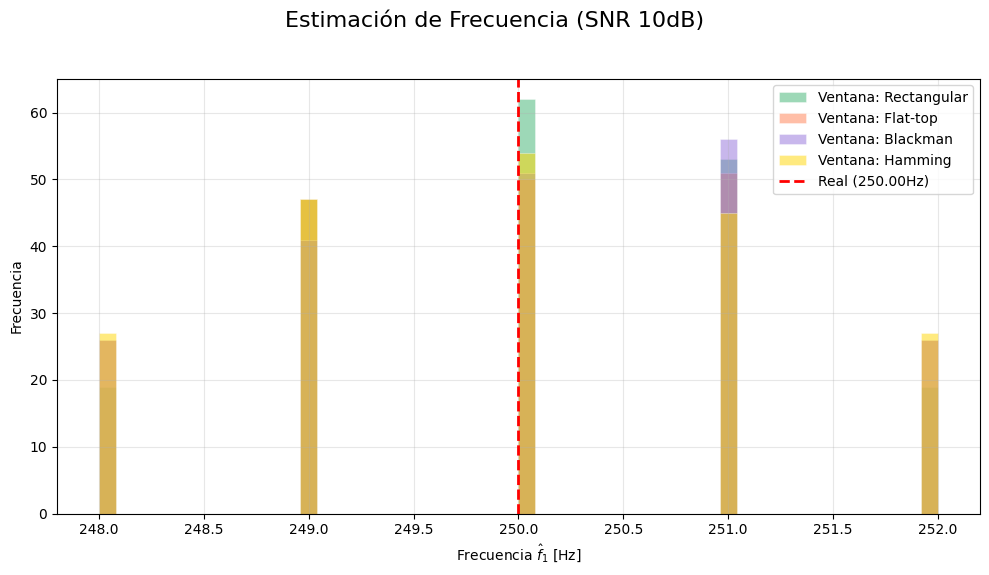

In [22]:
#%% SIMULACIÓN CON SNR = 10dB
sigma = np.sqrt(1 / (10**(snr_db[1] /10)))
hist_amp = {nombre: [] for nombre in ventanas.keys()}
hist_freq = {nombre: [] for nombre in ventanas.keys()}

#%% 200 realizaciones
for nombre, w in ventanas.items():
    cg = np.sum(w) / N # Ganancia coherente para corregir amplitud
    for t in range(R):
        na = np.random.normal(0, sigma, N)
        fr = np.random.uniform(-2, 2)
        Omega1 = Omega0 + fr * (2 * np.pi / N)
        f1_hz = Omega1 * fs / (2 * np.pi)
        t, x_pura = MT_Senoidal(a0, 0, f1_hz, N, fs)
        x_ruidosa = x_pura + na
        
        #X = mi_funcion_DFT(x_ruidosa * w)
        X = np.fft.fft(x_ruidosa * w)
                
        estim_amp = np.abs(X[int(N/4)]) / (N * cg / 2)
        hist_amp[nombre].append(estim_amp)
        
        estim_frec = np.argmax(np.abs(X[:N//2]))
        hist_freq[nombre].append(estim_frec * (fs / N))

#%% FIGURA 3: ESTIMACIÓN DE AMPLITUD (SNR 10dB)
colores = ['skyblue', 'salmon', 'lightgreen', 'orange']

fig1, ax = plt.subplots(figsize=(10, 6))
fig1.suptitle(f'Estimación de Amplitud (SNR {snr_db[1]}dB)', fontsize=16)

for i, (nombre, datos) in enumerate(hist_amp.items()):
    color_actual = colores[i % len(colores)]
    
    ax.hist(datos, bins=50, alpha=0.5, color=color_actual, 
            edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax.axvline(a0, color='red', linestyle='--', linewidth=2, label=f'Real (${a0:.2f}$)')

ax.set_xlabel('Amplitud $\hat{a}_1$')
ax.set_ylabel('Frecuencia')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#%% FIGURA 4: ESTIMACIÓN DE FRECUENCIA (SNR 10dB)
colores_freq = ['mediumseagreen', 'coral', 'mediumpurple', 'gold']

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.suptitle(f'Estimación de Frecuencia (SNR {snr_db[1]}dB)', fontsize=16)

f0_hz = (Omega0 * fs) / (2 * np.pi) 

for i, (nombre, datos) in enumerate(hist_freq.items()):
    color_actual = colores_freq[i % len(colores_freq)]
    
    ax2.hist(datos, bins=50, alpha=0.5, color=color_actual, 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')


ax2.axvline(f0_hz, color='red', linestyle='--', linewidth=2, label=f'Real ({f0_hz:0.2f}Hz)')

ax2.set_xlabel('Frecuencia $\hat{f}_1$ [Hz]')
ax2.set_ylabel('Frecuencia')
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. Tablas comparativas para 10dB

In [23]:
#%% TABLAS DE ESTIMACIÓN DE AMPLITUD Y FRECUENCIA 10dB

# --- TABLA 1: ESTIMACIÓN DE AMPLITUD ---
print("\n" + "="*70)
print(f"{'ESTIMACIÓN DE AMPLITUD (SNR ' + str(snr_db[1]) + ' dB)':^70}")
print("="*70)
print(f"{'Ventana':<20} | {'Sesgo (sa)':>20} | {'Varianza (va)':>20}")
print("-"*70)

for nombre in ventanas.keys():
    datos = hist_amp[nombre]
    mu_a = np.mean(datos)
    sa = mu_a - a0           
    va = np.var(datos)       
    label = nombre if nombre != 'Hamming' else 'Hamming (otras)'
    print(f"{label:<20} | {sa:>20.6f} | {va:>20.6e}")

print("-" * 70)

# --- TABLA 2: ESTIMACIÓN DE FRECUENCIA ---
print("\n" + "="*70)
print(f"{'ESTIMACIÓN DE FRECUENCIA (SNR ' + str(snr_db[1]) + ' dB)':^70}")
print("="*70)
print(f"{'Ventana':<20} | {'Sesgo (sf)':>20} | {'Varianza (vf)':>20}")
print("-"*70)

for nombre in ventanas.keys():
    datos = hist_freq[nombre]
    mu_f = np.mean(datos)
    sf = mu_f - f0_hz        # Sesgo respecto a la frecuencia real
    vf = np.var(datos)       # Varianza de la estimación de frecuencia
    
    label = nombre if nombre != 'Hamming' else 'Hamming (otras)'
    print(f"{label:<20} | {sf:>20.6f} | {vf:>20.6e}")

print("="*70)



                  ESTIMACIÓN DE AMPLITUD (SNR 10 dB)                  
Ventana              |           Sesgo (sa) |        Varianza (va)
----------------------------------------------------------------------
Rectangular          |            -0.835922 |         2.326042e-01
Flat-top             |            -0.123309 |         2.253193e-02
Blackman             |            -0.484349 |         1.399696e-01
Hamming (otras)      |            -0.756614 |         2.619237e-01
----------------------------------------------------------------------

                 ESTIMACIÓN DE FRECUENCIA (SNR 10 dB)                 
Ventana              |           Sesgo (sf) |        Varianza (vf)
----------------------------------------------------------------------
Rectangular          |             0.030000 |         1.259100e+00
Flat-top             |             0.020000 |         1.529600e+00
Blackman             |             0.075000 |         1.519375e+00
Hamming (otras)      |            -0.010

## 6. Bonus (implementación de Zero Padding para SNR de 3dB)

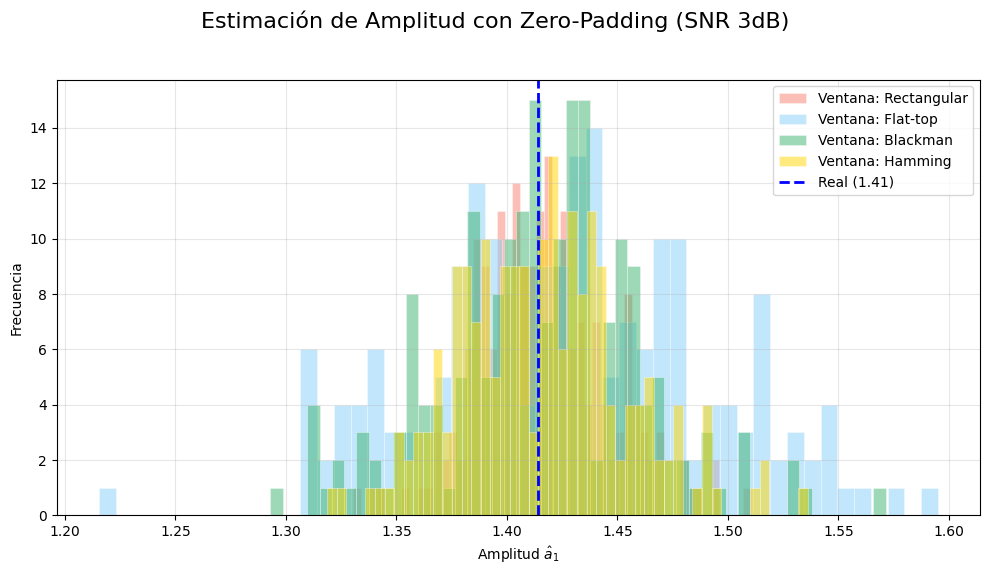

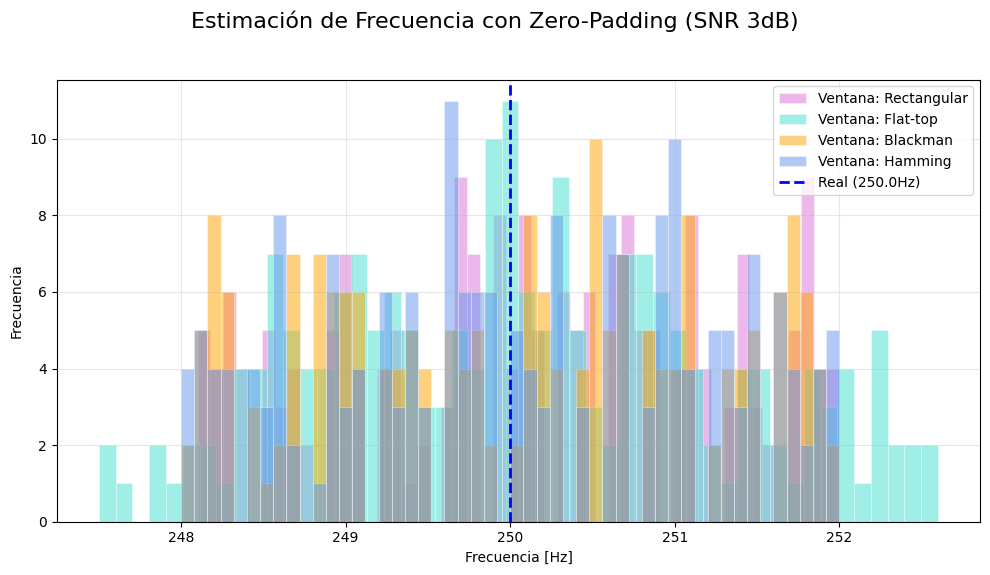

In [24]:
#%% BONUS con SNR 3dB
N_pad = N * 10  # Zero padding x10
hist_amp_bonus = {k: [] for k in ventanas.keys()}
hist_freq_bonus = {k: [] for k in ventanas.keys()}
sigma = np.sqrt(1 / (10**(snr_db[0] /10)))

for nombre, w in ventanas.items():
    cg = np.sum(w) / N
    for i in range(R):
        na = np.random.normal(0, sigma, N)
        fr = np.random.uniform(-2, 2)
        Omega1 = Omega0 + fr * (2 * np.pi / N)
        f1_hz = Omega1 * fs / (2 * np.pi)
        t, x_pura = MT_Senoidal(a0, 0, f1_hz, N, fs)
        x_ruidosa = x_pura + na
        
        X_pad = np.fft.fft(x_ruidosa * w, n=N_pad)
        
        idx_max = np.argmax(np.abs(X_pad[:N_pad//2]))
        estim_frec_bonus = idx_max * (fs / N_pad)
        
        estim_amp_bonus = np.abs(X_pad[idx_max]) / (N * cg / 2)
        
        hist_amp_bonus[nombre].append(estim_amp_bonus)
        hist_freq_bonus[nombre].append(estim_frec_bonus)
        
#%% FIGURA 5: PLOTEO DE AMPLITUD (SNR 3dB)
fig3, ax3 = plt.subplots(figsize=(10, 6))
fig3.suptitle(f'Estimación de Amplitud con Zero-Padding (SNR {snr_db[0]}dB)', fontsize=16)

colores_amp = ['salmon', 'lightskyblue', 'mediumseagreen', 'gold']

for i, (nombre, datos) in enumerate(hist_amp_bonus.items()):
    ax3.hist(datos, bins=50, alpha=0.5, color=colores_amp[i % len(colores_amp)], 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax3.axvline(a0, color='blue', linestyle='--', linewidth=2, label=f'Real ({a0:.2f})')

ax3.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax3.set_xlabel('Amplitud $\hat{a}_1$')
ax3.set_ylabel('Frecuencia')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#%% FIGURA 6: PLOTEO DE FRECUENCIA (SNR 3dB)
fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.suptitle(f'Estimación de Frecuencia con Zero-Padding (SNR {snr_db[0]}dB)', fontsize=16)

f0_hz = (Omega0 * fs) / (2 * np.pi) 
colores_freq = ['orchid', 'turquoise', 'orange', 'cornflowerblue']

for i, (nombre, datos) in enumerate(hist_freq_bonus.items()):
    ax4.hist(datos, bins=50, alpha=0.5, color=colores_freq[i % len(colores_freq)], 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax4.axvline(f0_hz, color='blue', linestyle='--', linewidth=2, label=f'Real ({f0_hz:.1f}Hz)')

ax4.set_xlabel('Frecuencia [Hz]')
ax4.set_ylabel('Frecuencia')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 7. Bonus (implementación de Zero Padding para SNR de 10dB)

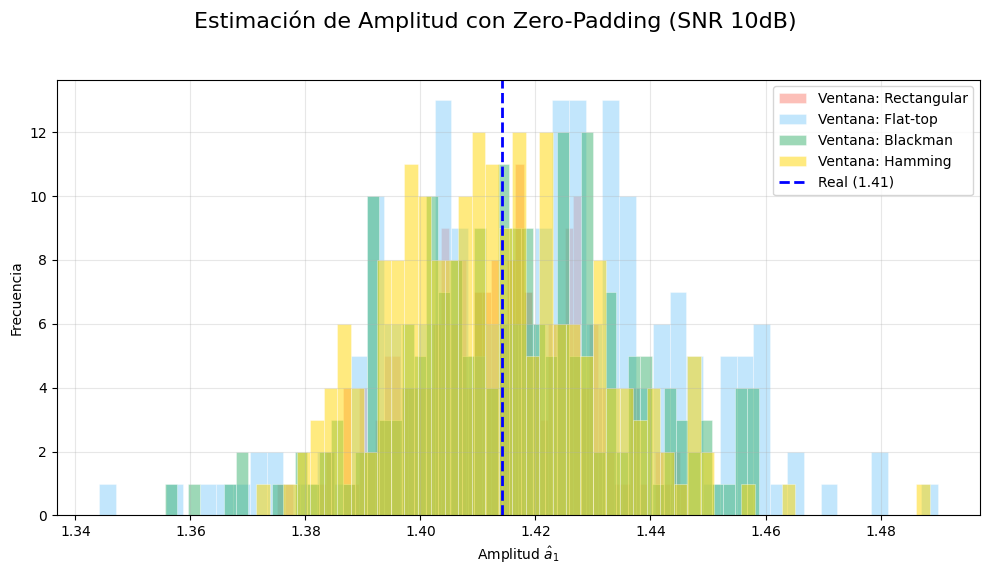

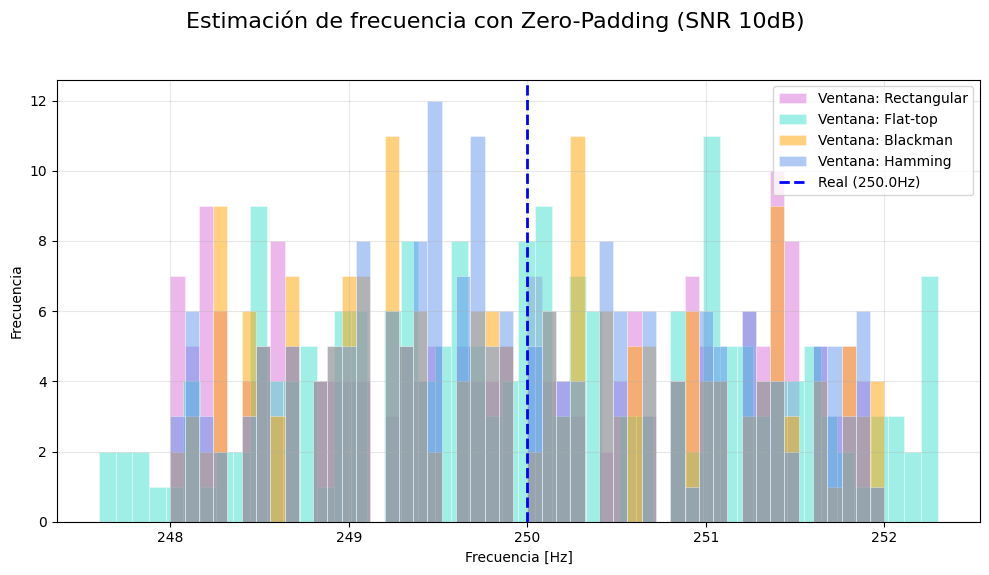

In [25]:
#%% BONUS con SNR 10dB
hist_amp_bonus = {k: [] for k in ventanas.keys()}
hist_freq_bonus = {k: [] for k in ventanas.keys()}
sigma = np.sqrt(1 / (10**(snr_db[1] /10)))

for nombre, w in ventanas.items():
    cg = np.sum(w) / N
    for i in range(R):
        na = np.random.normal(0, sigma, N)
        fr = np.random.uniform(-2, 2)
        Omega1 = Omega0 + fr * (2 * np.pi / N)
        f1_hz = Omega1 * fs / (2 * np.pi)
        t, x_pura = MT_Senoidal(a0, 0, f1_hz, N, fs)
        x_ruidosa = x_pura + na
        
        X_pad = np.fft.fft(x_ruidosa * w, n=N_pad)
        
        idx_max = np.argmax(np.abs(X_pad[:N_pad//2]))
        estim_frec_bonus = idx_max * (fs / N_pad)
        
        estim_amp_bonus = np.abs(X_pad[idx_max]) / (N * cg / 2)
        
        hist_amp_bonus[nombre].append(estim_amp_bonus)
        hist_freq_bonus[nombre].append(estim_frec_bonus)
        
#%% FIGURA 7: PLOTEO DE AMPLITUD (SNR 10dB)
fig3, ax3 = plt.subplots(figsize=(10, 6))
fig3.suptitle(f'Estimación de Amplitud con Zero-Padding (SNR {snr_db[1]}dB)', fontsize=16)

colores_amp = ['salmon', 'lightskyblue', 'mediumseagreen', 'gold']

for i, (nombre, datos) in enumerate(hist_amp_bonus.items()):
    ax3.hist(datos, bins=50, alpha=0.5, color=colores_amp[i % len(colores_amp)], 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax3.axvline(a0, color='blue', linestyle='--', linewidth=2, label=f'Real ({a0:.2f})')

ax3.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax3.set_xlabel('Amplitud $\hat{a}_1$')
ax3.set_ylabel('Frecuencia')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#%% FIGURA 8: PLOTEO DE FRECUENCIA (SNR 10dB)
fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.suptitle(f'Estimación de frecuencia con Zero-Padding (SNR {snr_db[1]}dB)', fontsize=16)

f0_hz = (Omega0 * fs) / (2 * np.pi) 
colores_freq = ['orchid', 'turquoise', 'orange', 'cornflowerblue']

for i, (nombre, datos) in enumerate(hist_freq_bonus.items()):
    ax4.hist(datos, bins=50, alpha=0.5, color=colores_freq[i % len(colores_freq)], 
             edgecolor='white', linewidth=0.5, label=f'Ventana: {nombre}')

ax4.axvline(f0_hz, color='blue', linestyle='--', linewidth=2, label=f'Real ({f0_hz:.1f}Hz)')

ax4.set_xlabel('Frecuencia [Hz]')
ax4.set_ylabel('Frecuencia')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()